<a href="https://colab.research.google.com/github/koffifidelek59-collab/piggy-cast/blob/main/MediCare_Hospital_Analytics/MediCare-Hospital-Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# MIT License
#
#@title Copyright (c) 2026 KOUAME Koffi Fidèle { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

### Open in Google Colab

You can run this notebook directly in [Google Colab](https://colab.research.google.com) without installing anything locally. Just click the badge below:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/koffifidelek59-collab/piggy-cast/blob/main/MediCare_Hospital_Analytics/MediCare-Hospital-Analytics.ipynb)

💡**Note on Hardware**

The whole analysis runs on a standard CPU in under one minute. No GPU is required.

# Data Analysis Internship: MediCare+ Hospital Analytics - Data Quality, Measures and Decision Support on 247 Admissions

## Author
1. KOUAME Koffi Fidèle - WASCAL IMP-EGH (Energy and Green Hydrogen Technology, System Analysis), Abdou Moumouni University, Niamey.

## Contact info
Any correspondence via KOUAME Koffi Fidèle - koffifidelek59@gmail.com

## Overview

This notebook takes the MediCare+ admission register from **raw data** to **decision support**, following the chain required by the brief:

> **Raw data → Clean data → Measures & KPIs → Insights → Decision support**

The register holds **247 admission episodes** for one calendar year (2023). Each episode records the patient, the diagnosis, the severity grade, the attending physician, the admission and discharge dates, the billed amount and the insurance cover.

The main contributions of this notebook are:

*   **A reproducible cleaning:** every quality defect is detected by a rule, counted, flagged and kept. No row is deleted.
*   **Measures computed on the right base:** every indicator states the population it is computed on, so that a figure copied into a slide keeps its meaning.
*   **Tested insights:** every segment difference is reported with its statistical test, so that a pattern produced by chance is not presented as a finding.

## Study Goals
By the end of this notebook, the reader will be able to:

1. **Audit the register**: identify the two defects that govern every financial and operational figure (placeholder bills and impossible stays).
2. **Clean without losing information**: apply flags rather than deletions, and justify every decision.
3. **Compute the indicators**: volume, case mix, acuity, cover, length of stay and validated revenue, each on its correct base.
4. **Test before concluding**: separate real signals (length of stay drives the bill) from apparent ones (monthly peaks, severity ordering).
5. **Support decisions**: translate each finding into an action for finance, operations and data governance.

# Table of Contents
*   [1. Understanding the Analytical Task](#analytical-task)
*   [2. Target Audience](#target-audience)
*   [3. Software Requirements](#software-requirements)
*   [4. Data Description & Datasheet](#data-description)
*   [5. Data Loading](#data-loading)
*   [6. Data Quality Audit](#data-quality)
*   [7. Data Cleaning](#data-cleaning)
*   [8. Measures & KPIs](#measures-kpis)
*   [9. Results & Discussion](#results-and-discussion)
*   [10. Statistical Tests](#statistical-tests)
*   [11. Insights & Recommendations](#insights)
*   [12. Interactive Dashboard](#dashboard)
*   [13. Limitations & Future Works](#limitations)
*   [14. References](#references)

<a name="analytical-task"></a>
# 1. Understanding the Analytical Task

Before computing any indicator, it is important to understand **what** the register can support, **why** a naive reading misleads, and **where** each figure is allowed to be used.

## What Are We Measuring?

The register describes hospital **admission episodes**. One row is one stay: a patient may appear several times.

| Question | Indicator | Unit |
|---|---|---|
| How much activity? | Admission episodes, distinct patients | count |
| What activity? | Case mix by diagnosis, severity grade | count, % |
| Who pays? | Insurance cover | % |
| How long? | Length of stay (LOS) | days |
| How much revenue? | Validated billed amount | currency units |

## Why a Naive Reading Misleads

The file is **complete**: no cell is empty in the identifying and clinical columns. A completeness audit therefore reports no problem. Two defects are nevertheless present:

- **Placeholder bills.** Two amounts, 999 and 3,852, are repeated on 195 of 247 episodes. Both are legal values inside the observed range, so no range check detects them.
- **Impossible stays.** 29 episodes record a discharge date earlier than the admission date.

> **Key takeaway:** A figure computed on the raw columns looks complete and is wrong. Every indicator in this notebook is computed on the rows that can support it, and states that base.

<a name="target-audience"></a>
# 2. Target Audience

This notebook is intended for:

*   **Hospital management**, who decide on capacity, staffing and financial counselling.
*   **The finance department**, who must know which revenue figure is usable.
*   **Data governance and IT**, who own the admission and billing systems where the defects originate.
*   **Data analysts and students**, who need a reproducible example of the chain from raw data to decision support.

The ideal reader has a working knowledge of Python (pandas, matplotlib) and of basic descriptive and inferential statistics.

<a name="software-requirements"></a>
# 3. Software Requirements

The analysis uses the Python scientific stack only: `pandas`, `numpy`, `scipy` and `matplotlib`. No spreadsheet and no business-intelligence tool is used at any stage.

`pip freeze > requirements.txt`

In [2]:
# ===============================================================
# @title 📦 Install dependencies
# ===============================================================

# Install pandas and numpy for data manipulation
!pip install -q pandas numpy

# Install scipy for the statistical tests
!pip install -q scipy

# Install matplotlib for the figures
!pip install -q matplotlib

In [3]:
# @title Import libraries and message function

# Standard library imports
import os
import json
import urllib.request
from pprint import pprint

# Third-party imports
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from IPython.display import HTML, display


def show_message(msg: str, color: str = "#1f77b4"):
    """
    Displays a colored message in the notebook output.

    Args:
        msg: The message string to display.
        color: The color of the message text (default is blue).
    """
    display(HTML(f"<p style='color:{color}; font-size:16px; font-weight:bold'>{msg}</p>"))

In [4]:
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"scipy version: {scipy.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")

pandas version: 3.0.6
numpy version: 2.4.6
scipy version: 1.17.1
matplotlib version: 3.11.2


In [5]:
# ================================================================
# @title 🎨 Figure standard (one style for every figure of the report)
# ================================================================
# Every figure is drawn at the width of the report text (16 cm = 6.3 in),
# so that fonts appear at their true size once inserted in the PDF.
# One colour per role, never per bar:
#   - PRIMARY  : the series being measured
#   - MUTED    : data shown for reference only (not for decisions)
#   - CRITICAL : a data defect, always named in a label or legend
#   - SEVERITY : one-hue ordinal ramp, light (Low) to dark (High)
#   - CATEGORY : fixed categorical order, validated for colour-vision deficiency

FIG_WIDTH = 6.3          # inches, text width of the A4 report
PRIMARY = "#2a78d6"
MUTED = "#b4b2ab"
CRITICAL = "#d03b3b"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
GRID = "#e1e0d9"
AXIS = "#8a8983"
SEVERITY_COLORS = {"Low": "#86b6ef", "Medium": "#2a78d6", "High": "#104281"}
CATEGORY_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]


def set_plot_style():
    """
    Applies the report figure standard to matplotlib.

    Sans-serif text at 9 pt, hairline axes, horizontal grid only,
    no top or right spine, white background.
    """
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Liberation Sans", "Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 9,
        "axes.titlesize": 9.5,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 8,
        "axes.labelsize": 9,
        "axes.labelcolor": INK_SECONDARY,
        "axes.edgecolor": AXIS,
        "axes.linewidth": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "grid.color": GRID,
        "grid.linewidth": 0.6,
        "xtick.color": INK_SECONDARY,
        "ytick.color": INK_SECONDARY,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 3,
        "ytick.major.size": 0,
        "legend.fontsize": 8.5,
        "legend.frameon": False,
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "pdf.fonttype": 42,
    })


def thousands(x: float, _=None) -> str:
    """
    Formats an axis tick with a thousands separator.

    Args:
        x: The tick value.

    Returns:
        The formatted tick label, for example 150,000.
    """
    return f"{x:,.0f}"


set_plot_style()
print("✅ Figure standard applied.")

✅ Figure standard applied.


<a name="data-description"></a>
# 4. Data Description & Datasheet

The data is the MediCare+ admission register supplied for the internship, translated to English column names (`hospital_raw.csv`).

## Datasheet for the Register

Datasheets for Datasets ([Gebru et al., 2021](https://arxiv.org/abs/1803.09010)) document key properties of a dataset to support responsible, informed use. Below is a condensed datasheet for the register.

### Motivation
- **What is the purpose of this dataset?** To support the analysis of hospital activity, case mix, length of stay and revenue for one facility.
- **Who created it?** The MediCare+ admission and billing systems, supplied as a training dataset for the data analysis internship.

### Composition
- **What does an instance represent?** One admission episode.
- **Number of instances:** 247 episodes, 75 distinct patients, 7 physicians, 10 diagnoses.
- **Period:** 1 January 2023 to 28 December 2023.
- **Key columns:**

| Column | Content |
|---|---|
| `EpisodeID` | Unique episode identifier (EP-0001 to EP-0247) |
| `PatientName`, `Age`, `Gender` | Patient identity and demographics |
| `Diagnosis`, `Severity` | Main diagnosis (10 values), severity grade (Low, Medium, High) |
| `Doctor` | Attending physician (7 values) |
| `AdmitDate`, `DischargeDate` | Dates of the stay |
| `Bill` | Billed amount, currency units |
| `Insurance` | Private insurance, Government insurance, Uninsured |

### Collection Process
- Records are entered at admission and at discharge. The bill is captured by the billing system.
- The file as supplied also carries helper columns (`LengthOfStay`, `BillValid`, `DateError`, `BillIsPlaceholder`). **This notebook does not trust them**: it recomputes every flag from the primary columns and then checks that both agree.

### Uses
- **Intended use:** Descriptive analysis, decision support, training.
- **Potential misuse:** Publishing the raw sum of the `Bill` column as revenue, or benchmarking physicians on a sample of 24 to 42 episodes each.

### Limitations & Gaps
- One facility, one year: no trend and no comparison between sites is possible.
- No ward, procedure or cost-of-care column: revenue is a billed amount, not a cost.

<a name="data-loading"></a>

# 5. Data Loading

⚠️**Data Access Options**

This notebook offers two ways to access the register:

* Option 1 - Local copy: if the notebook runs from the project folder, the register is read from `./data/hospital_raw.csv`.

* Option 2 - GitHub: if the local copy is missing (for example in Google Colab), the register is downloaded from the project repository. No authentication is required.

In [6]:
# @title Drive Location for data, plots and results

def make_directory(drive_path: str):
    """
    Checks if a directory exists at the given path and creates it if it doesn't.

    Args:
        drive_path: The path to the directory.
    """
    if not os.path.exists(drive_path):
        os.makedirs(drive_path)
        print(f"Folder created: {drive_path}")
    else:
        print(f"Folder already exists: {drive_path}")


# Adjust the paths according to your directory structure.
drive_data_path = "./data/"
drive_plots_path = "./figures/"
drive_results_path = "./results/"

make_directory(drive_data_path)
make_directory(drive_plots_path)
make_directory(drive_results_path)

Folder already exists: ./data/
Folder already exists: ./figures/
Folder already exists: ./results/


In [7]:
# @title 🏥 Data Access Options: Local copy or GitHub
# ===============================================================
# Option 1 → Read the local copy in ./data/
# Option 2 → Download the register from the project repository
# ===============================================================

RAW_FILE = drive_data_path + "hospital_raw.csv"
GITHUB_RAW_URL = ("https://raw.githubusercontent.com/koffifidelek59-collab/piggy-cast/"
                  "main/MediCare_Hospital_Analytics/data/hospital_raw.csv")

if os.path.exists(RAW_FILE):
    show_message(f"✅ Local register found: {RAW_FILE}", "#228B22")
else:
    show_message("🌍 Local register not found. Downloading from GitHub...", "#1f77b4")
    urllib.request.urlretrieve(GITHUB_RAW_URL, RAW_FILE)
    show_message(f"✅ Register downloaded to {RAW_FILE}", "#228B22")

In [8]:
# @title Load the raw register

# Dates are parsed on load; every other column is kept exactly as supplied.
raw_df = pd.read_csv(RAW_FILE, parse_dates=["AdmitDate", "DischargeDate"])
print(f"raw_df size: {raw_df.shape}")
print("First 5 rows of the raw register:")
raw_df.head()

raw_df size: (247, 23)
First 5 rows of the raw register:


,EpisodeID,PatientName,Age,AgeBand,AgeBandOrder,Gender,Diagnosis,Severity,SeverityRank,Doctor,...,AdmitMonth,AdmitMonthName,AdmitQuarter,AdmitWeekday,Bill,BillValid,Insurance,IsInsured,DateError,BillIsPlaceholder
0,EP-0001,Mariam Khaled,22,19-30,2,Male,Fracture,Low,1,Dr. Yasmin Mahmoud,...,1,Jan,1,Sunday,5339,5339.0,Government insurance,True,False,False
1,EP-0002,Mariam Youssef,57,46-60,4,Female,Chronic allergy,Low,1,Dr. Yasmin Mahmoud,...,1,Jan,1,Tuesday,999,NaN,Private insurance,True,True,True
2,EP-0003,Ibrahim Hassan,56,46-60,4,Male,Migraine,Low,1,Dr. Yasmin Mahmoud,...,1,Jan,1,Thursday,3852,NaN,Uninsured,False,False,True
3,EP-0004,Mariam Youssef,84,76+,6,Female,Diabetes,Low,1,Dr. Yasmin Mahmoud,...,1,Jan,1,Thursday,3920,3920.0,Government insurance,True,False,False
4,EP-0005,Yasmin Hassan,26,19-30,2,Male,Kidney failure,High,3,Dr. Ahmed Ali,...,1,Jan,1,Thursday,999,NaN,Government insurance,True,False,True


In [9]:
# @title Column types and missing values

overview = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing": raw_df.isna().sum(),
    "distinct": raw_df.nunique(),
})
print(overview.to_string())

                            dtype  missing  distinct
EpisodeID                     str        0       247
PatientName                   str        0        75
Age                         int64        0        85
AgeBand                       str        0         6
AgeBandOrder                int64        0         6
Gender                        str        0         2
Diagnosis                     str        0        10
Severity                      str        0         3
SeverityRank                int64        0         3
Doctor                        str        0         7
AdmitDate          datetime64[us]        0       168
DischargeDate      datetime64[us]        0       188
LengthOfStay              float64       29        24
AdmitMonth                  int64        0        12
AdmitMonthName                str        0        12
AdmitQuarter                int64        0         4
AdmitWeekday                  str        0         7
Bill                        int64        0    

<a name="data-quality"></a>
# 6. Data Quality Audit

The audit runs six checks. The first four are the routine checks (identifiers, completeness, categories, ranges). The last two are the checks that find the defects: **repetition of an amount** and **chronology of the dates**.

In [10]:
# @title Routine checks: identifiers, completeness, categories, ranges

def routine_checks(df: pd.DataFrame) -> pd.DataFrame:
    """
    Runs the routine quality checks on the raw register.

    Args:
        df: The raw register.

    Returns:
        A DataFrame with one row per check and its result.
    """
    core_columns = ["EpisodeID", "PatientName", "Age", "Gender", "Diagnosis",
                    "Severity", "Doctor", "AdmitDate", "DischargeDate", "Bill", "Insurance"]
    rows = [
        ("Admission episodes", len(df)),
        ("Duplicate EpisodeID", int(df["EpisodeID"].duplicated().sum())),
        ("Fully duplicated rows", int(df.duplicated().sum())),
        ("Missing values in core columns", int(df[core_columns].isna().sum().sum())),
        ("Distinct patients", df["PatientName"].nunique()),
        ("Attending physicians", df["Doctor"].nunique()),
        ("Distinct diagnoses", df["Diagnosis"].nunique()),
        ("Age outside 0-110", int((~df["Age"].between(0, 110)).sum())),
        ("Bill below or equal to 0", int((df["Bill"] <= 0).sum())),
    ]
    return pd.DataFrame(rows, columns=["check", "result"])


print(routine_checks(raw_df).to_string(index=False))

print("\nCategory labels (spelling variants would appear here):")
for col in ["Gender", "Severity", "Insurance", "Diagnosis", "Doctor"]:
    print(f"  {col:<10}: {sorted(raw_df[col].unique())}")

                         check  result
            Admission episodes     247
           Duplicate EpisodeID       0
         Fully duplicated rows       0
Missing values in core columns       0
             Distinct patients      75
          Attending physicians       7
            Distinct diagnoses      10
             Age outside 0-110       0
      Bill below or equal to 0       0

Category labels (spelling variants would appear here):
  Gender    : ['Female', 'Male']
  Severity  : ['High', 'Low', 'Medium']
  Insurance : ['Government insurance', 'Private insurance', 'Uninsured']
  Diagnosis : ['Chronic allergy', 'Common cold', 'Diabetes', 'Fracture', 'Hypertension', 'Influenza', 'Kidney failure', 'Migraine', 'Pneumonia', 'Stroke']
  Doctor    : ['Dr. Ahmed Ali', 'Dr. Khaled Sami', 'Dr. Mohamed Hassan', 'Dr. Nour Khaled', 'Dr. Reem Abdallah', 'Dr. Sara Ibrahim', 'Dr. Yasmin Mahmoud']


**Remark** ✅

The routine checks find nothing: identifiers are unique, the core columns are complete, the category labels have no spelling variants and every amount is positive. A report that stopped here would declare the file clean. The two checks below show that it is not.

In [11]:
# @title Check 5: repetition of a billed amount

# A genuine billed amount depends on the stay and the care delivered, so the
# same amount should almost never repeat. An amount repeated many times is a
# default value written by the system, not a charge.
PLACEHOLDER_MIN_REPEAT = 10

bill_counts = raw_df["Bill"].value_counts()
placeholder_amounts = sorted(bill_counts[bill_counts >= PLACEHOLDER_MIN_REPEAT].index.tolist())

print("Most frequent billed amounts:")
print(bill_counts.head(6).to_string())
print(f"\nAmounts repeated on {PLACEHOLDER_MIN_REPEAT} episodes or more: {placeholder_amounts}")
print(f"Largest repeat among all other amounts: "
      f"{bill_counts[~bill_counts.index.isin(placeholder_amounts)].max()}")

Most frequent billed amounts:
Bill
999     100
3852     95
5339      1
3920      1
2873      1
3293      1

Amounts repeated on 10 episodes or more: [999, 3852]
Largest repeat among all other amounts: 1


In [12]:
# @title Check 6: chronology of the admission and discharge dates

los_from_dates = (raw_df["DischargeDate"] - raw_df["AdmitDate"]).dt.days
date_error = los_from_dates < 0

print(f"Episodes with discharge before admission: {date_error.sum()} "
      f"({date_error.mean() * 100:.1f}%)")
print(f"Most negative stay: {los_from_dates.min()} days")
print(f"Same-day discharges (stay of 0 days): {(los_from_dates == 0).sum()}")

Episodes with discharge before admission: 29 (11.7%)
Most negative stay: -5 days
Same-day discharges (stay of 0 days): 0


In [13]:
# @title Cross-check against the helper columns supplied with the file

placeholder_flag = raw_df["Bill"].isin(placeholder_amounts)

agreement = pd.Series({
    "DateError flag agrees with recomputed chronology": bool((raw_df["DateError"] == date_error).all()),
    "LengthOfStay agrees on valid stays": bool((raw_df.loc[~date_error, "LengthOfStay"] == los_from_dates[~date_error]).all()),
    "LengthOfStay is empty exactly on date errors": bool((raw_df["LengthOfStay"].isna() == date_error).all()),
    "BillIsPlaceholder agrees with recomputed flag": bool((raw_df["BillIsPlaceholder"] == placeholder_flag).all()),
})
print(agreement.to_string())

DateError flag agrees with recomputed chronology    True
LengthOfStay agrees on valid stays                  True
LengthOfStay is empty exactly on date errors        True
BillIsPlaceholder agrees with recomputed flag       True


**Remark** ✅

The flags recomputed from the primary columns agree exactly with the helper columns supplied with the file. The two defects are therefore confirmed by two independent routes.

In [14]:
# @title Quality summary table

quality_summary = pd.DataFrame([
    ("Admission episodes", len(raw_df), 100.0),
    ("Episodes with a placeholder bill", int(placeholder_flag.sum()), placeholder_flag.mean() * 100),
    ("  of which amount 999", int((raw_df["Bill"] == 999).sum()), (raw_df["Bill"] == 999).mean() * 100),
    ("  of which amount 3,852", int((raw_df["Bill"] == 3852).sum()), (raw_df["Bill"] == 3852).mean() * 100),
    ("Episodes usable for revenue", int((~placeholder_flag).sum()), (~placeholder_flag).mean() * 100),
    ("Episodes with an impossible stay", int(date_error.sum()), date_error.mean() * 100),
    ("Episodes usable for length of stay", int((~date_error).sum()), (~date_error).mean() * 100),
], columns=["item", "episodes", "share_%"])
quality_summary["share_%"] = quality_summary["share_%"].round(1)
quality_summary.to_csv(drive_results_path + "data_quality_summary.csv", index=False)
print(quality_summary.to_string(index=False))

                              item  episodes  share_%
                Admission episodes       247    100.0
  Episodes with a placeholder bill       195     78.9
               of which amount 999       100     40.5
             of which amount 3,852        95     38.5
       Episodes usable for revenue        52     21.1
  Episodes with an impossible stay        29     11.7
Episodes usable for length of stay       218     88.3


<a name="data-cleaning"></a>
# 7. Data Cleaning

The cleaning follows one principle: **flag, do not delete**. A row with a placeholder bill still carries a valid diagnosis, physician, severity and cover. Deleting it would discard the clinical record to repair one column.

| Problem | Count | Decision | Reason |
|---|---:|---|---|
| Placeholder bills (999, 3,852) | 195 | `Bill_clean` left empty, flag `BillIsPlaceholder` | 999 and 3,852 are defaults, not charges |
| Impossible stays | 29 | `LOS_valid` left empty, flag `DateError` | Zero would invent 29 same-day discharges |
| Insurance labels | 3 | Mapped to Private, Government, Uninsured | Short, stable keys for filters |
| Duplicates | 0 | None removed | Identifiers are unique |

**No row is deleted.** Every affected row keeps its flag, so a reader can include or exclude it and see the difference.

In [15]:
# @title Clean the register

def clean_register(df: pd.DataFrame, placeholder_amounts: list) -> pd.DataFrame:
    """
    Builds the analysis-ready register from the raw file.

    Args:
        df: The raw register.
        placeholder_amounts: The billed amounts identified as system defaults.

    Returns:
        The cleaned register, with the same 247 rows, the quality flags and
        the two decision columns Bill_clean and LOS_valid.
    """
    clean = df.copy()

    # Chronology of the stay, recomputed from the dates
    clean["LOS_raw"] = (clean["DischargeDate"] - clean["AdmitDate"]).dt.days
    clean["DateError"] = clean["LOS_raw"] < 0
    clean["LOS_valid"] = clean["LOS_raw"].where(~clean["DateError"])

    # Billing: placeholder amounts are kept in Bill but excluded from Bill_clean
    clean["BillIsPlaceholder"] = clean["Bill"].isin(placeholder_amounts)
    clean["Bill_clean"] = clean["Bill"].where(~clean["BillIsPlaceholder"]).astype(float)

    # Stable category keys
    clean["Insurance"] = clean["Insurance"].replace({
        "Private insurance": "Private",
        "Government insurance": "Government",
    })
    clean["IsInsured"] = clean["Insurance"] != "Uninsured"

    # Calendar keys
    clean["AdmitMonth"] = clean["AdmitDate"].dt.month
    clean["AdmitMonthName"] = clean["AdmitDate"].dt.strftime("%b")
    clean["AdmitQuarter"] = "Q" + clean["AdmitDate"].dt.quarter.astype(str)

    # Helper columns supplied with the file are replaced by the recomputed ones
    clean = clean.drop(columns=["LengthOfStay", "BillValid"])
    return clean


clean_df = clean_register(raw_df, placeholder_amounts)
clean_df.to_csv(drive_data_path + "hospital_clean.csv", index=False)

show_message(f"✅ Clean register saved: {clean_df.shape[0]} rows, {clean_df.shape[1]} columns", "#228B22")
print(f"Rows in raw file  : {len(raw_df)}")
print(f"Rows in clean file: {len(clean_df)}")
clean_df[["EpisodeID", "Diagnosis", "Severity", "LOS_raw", "LOS_valid", "DateError",
          "Bill", "Bill_clean", "BillIsPlaceholder", "Insurance"]].head(8)

Rows in raw file  : 247
Rows in clean file: 247


,EpisodeID,Diagnosis,Severity,LOS_raw,LOS_valid,DateError,Bill,Bill_clean,BillIsPlaceholder,Insurance
0,EP-0001,Fracture,Low,4,4.0,False,5339,5339.0,False,Government
1,EP-0002,Chronic allergy,Low,-3,NaN,True,999,NaN,True,Private
2,EP-0003,Migraine,Low,6,6.0,False,3852,NaN,True,Uninsured
3,EP-0004,Diabetes,Low,5,5.0,False,3920,3920.0,False,Government
4,EP-0005,Kidney failure,High,2,2.0,False,999,NaN,True,Government
5,EP-0006,Chronic allergy,Low,4,4.0,False,999,NaN,True,Private
6,EP-0007,Chronic allergy,High,4,4.0,False,999,NaN,True,Government
7,EP-0008,Hypertension,Medium,20,20.0,False,999,NaN,True,Private


<a name="measures-kpis"></a>
# 8. Measures & KPIs

Each indicator is computed on the population that can support it, and that population is stored with the value.

| Indicator | Definition | Base |
|---|---|---|
| Admission episodes | Number of rows | all 247 |
| Distinct patients | Unique `PatientName` | all 247 |
| High severity share | Episodes graded High / all episodes | all 247 |
| Uninsured share | Uninsured episodes / all episodes | all 247 |
| Mean and median LOS | Mean and median of `LOS_valid` | 218 valid stays |
| Validated revenue | Sum of `Bill_clean` | 52 genuine bills |
| Mean validated bill | Mean of `Bill_clean` | 52 genuine bills |
| Raw bill column sum | Sum of `Bill` | shown for reconciliation only |

In [16]:
# @title Compute the KPI table

def compute_kpis(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes the headline indicators with the base each one rests on.

    Args:
        df: The cleaned register.

    Returns:
        A DataFrame with columns indicator, value and base.
    """
    n = len(df)
    los = df["LOS_valid"].dropna()
    bills = df["Bill_clean"].dropna()
    rows = [
        ("Admission episodes", n, "all episodes"),
        ("Distinct patients", df["PatientName"].nunique(), "all episodes"),
        ("Attending physicians", df["Doctor"].nunique(), "all episodes"),
        ("Distinct diagnoses", df["Diagnosis"].nunique(), "all episodes"),
        ("Mean patient age (years)", round(df["Age"].mean(), 1), "all episodes"),
        ("Female share (%)", round((df["Gender"] == "Female").mean() * 100, 1), "all episodes"),
        ("High severity share (%)", round((df["Severity"] == "High").mean() * 100, 1), "all episodes"),
        ("Uninsured share (%)", round((df["Insurance"] == "Uninsured").mean() * 100, 1), "all episodes"),
        ("Mean length of stay (days)", round(los.mean(), 2), f"{len(los)} valid stays"),
        ("Median length of stay (days)", round(los.median(), 1), f"{len(los)} valid stays"),
        ("Validated revenue", round(bills.sum(), 0), f"{len(bills)} genuine bills"),
        ("Mean validated bill", round(bills.mean(), 0), f"{len(bills)} genuine bills"),
        ("Median validated bill", round(bills.median(), 0), f"{len(bills)} genuine bills"),
        ("Raw bill column sum", round(df["Bill"].sum(), 0), "not for decisions"),
    ]
    return pd.DataFrame(rows, columns=["indicator", "value", "base"])


kpi_df = compute_kpis(clean_df)
kpi_df.to_csv(drive_results_path + "kpis.csv", index=False)
print(kpi_df.to_string(index=False))

                   indicator     value              base
          Admission episodes    247.00      all episodes
           Distinct patients     75.00      all episodes
        Attending physicians      7.00      all episodes
          Distinct diagnoses     10.00      all episodes
    Mean patient age (years)     47.40      all episodes
            Female share (%)     52.60      all episodes
     High severity share (%)     36.00      all episodes
         Uninsured share (%)     29.10      all episodes
  Mean length of stay (days)      6.74   218 valid stays
Median length of stay (days)      4.00   218 valid stays
           Validated revenue 153155.00  52 genuine bills
         Mean validated bill   2945.00  52 genuine bills
       Median validated bill   2704.00  52 genuine bills
         Raw bill column sum 618995.00 not for decisions


In [17]:
# @title Aggregated tables by diagnosis, physician, insurance, severity and month

def summarise_by(df: pd.DataFrame, key: str) -> pd.DataFrame:
    """
    Summarises volume, length of stay and validated revenue for one dimension.

    Args:
        df: The cleaned register.
        key: The column to group by.

    Returns:
        A DataFrame with one row per category of the dimension.
    """
    table = df.groupby(key).agg(
        episodes=("EpisodeID", "count"),
        high_severity=("Severity", lambda s: int((s == "High").sum())),
        valid_stays=("LOS_valid", "count"),
        mean_los=("LOS_valid", "mean"),
        genuine_bills=("Bill_clean", "count"),
        validated_revenue=("Bill_clean", "sum"),
        mean_validated_bill=("Bill_clean", "mean"),
    )
    table["share_%"] = table["episodes"] / len(df) * 100
    return table.round(2).sort_values("episodes", ascending=False)


summary_tables: dict = {}
for key in ["Diagnosis", "Doctor", "Insurance", "Severity", "AdmitMonth", "AgeBand"]:
    summary_tables[key] = summarise_by(clean_df, key)
    summary_tables[key].to_csv(drive_results_path + f"by_{key.lower()}.csv")

print(summary_tables["Diagnosis"].to_string())

                 episodes  high_severity  valid_stays  mean_los  genuine_bills  validated_revenue  mean_validated_bill  share_%
Diagnosis                                                                                                                      
Influenza              40             13           37      6.59              8            20484.0              2560.50    16.19
Fracture               37             10           33      5.39             13            36393.0              2799.46    14.98
Chronic allergy        34             16           30      7.40              4             7495.0              1873.75    13.77
Common cold            31             15           28      8.32              7            21826.0              3118.00    12.55
Diabetes               28             13           25      6.00              5            19843.0              3968.60    11.34
Hypertension           24              5           19      6.63              6            27199.0       

<a name="results-and-discussion"></a>
# 9. Results & Discussion

This section produces the twelve figures of the report. Each function draws one figure, saves it in PNG at 300 dpi, and returns it.

All figures follow the same standard: one colour per role, values written only where the reader needs them, the message of the figure in the report caption rather than inside the plot.

In [18]:
# @title Save a figure in PNG

def save_figure(fig: plt.Figure, name: str):
    """
    Saves a figure in the plots folder, in PNG at 300 dpi.

    Args:
        fig: The matplotlib figure.
        name: The file name without extension.
    """
    fig.savefig(drive_plots_path + f"{name}.png", dpi=300, bbox_inches="tight")
    print(f"Saved: {drive_plots_path}{name}.png")


def label_bars_h(ax: plt.Axes, bars, labels: list, pad: float = 0.01):
    """
    Writes one label at the end of each horizontal bar.

    Args:
        ax: The axes holding the bars.
        bars: The bar container returned by ax.barh.
        labels: The text to write, one per bar.
        pad: The gap between bar end and label, as a share of the x range.
    """
    x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    for bar, text in zip(bars, labels):
        ax.text(bar.get_width() + pad * x_range, bar.get_y() + bar.get_height() / 2,
                text, va="center", ha="left", fontsize=8, color=INK, zorder=4,
                bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.4})


def label_bars_v(ax: plt.Axes, bars, labels: list, pad: float = 0.015):
    """
    Writes one label above each vertical bar.

    Args:
        ax: The axes holding the bars.
        bars: The bar container returned by ax.bar.
        labels: The text to write, one per bar.
        pad: The gap between bar top and label, as a share of the y range.
    """
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    for bar, text in zip(bars, labels):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + pad * y_range,
                text, va="bottom", ha="center", fontsize=8, color=INK, zorder=4,
                bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.4})

## Figure 1 - The two data quality defects

Panel (a) splits the 247 bills by status; panel (b) splits the 247 stays by status. Defects are drawn in red and named on the axis.

Saved: ./figures/01_data_quality.png


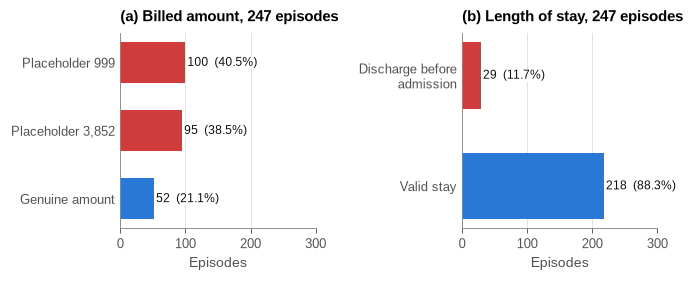

In [19]:
# @title Figure 1: Billing status and stay status

def plot_data_quality(df: pd.DataFrame) -> plt.Figure:
    """
    Plots the number of episodes affected by each data quality defect.

    Args:
        df: The cleaned register.

    Returns:
        The matplotlib figure.
    """
    n = len(df)
    bill_status = pd.Series({
        "Genuine amount": int((~df["BillIsPlaceholder"]).sum()),
        "Placeholder 3,852": int((df["Bill"] == 3852).sum()),
        "Placeholder 999": int((df["Bill"] == 999).sum()),
    })
    stay_status = pd.Series({
        "Valid stay": int((~df["DateError"]).sum()),
        "Discharge before\nadmission": int(df["DateError"].sum()),
    })

    fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, 2.3),
                             gridspec_kw={"width_ratios": [1, 1], "wspace": 0.75})
    panels = [(axes[0], bill_status, "(a) Billed amount, 247 episodes",
               [PRIMARY, CRITICAL, CRITICAL]),
              (axes[1], stay_status, "(b) Length of stay, 247 episodes",
               [PRIMARY, CRITICAL])]
    for ax, series, title, colors in panels:
        bars = ax.barh(series.index, series.values, color=colors, height=0.6)
        ax.set_xlim(0, 300)
        ax.set_xlabel("Episodes")
        ax.set_title(title)
        ax.xaxis.grid(True)
        ax.set_axisbelow(True)
        label_bars_h(ax, bars, [f"{v}  ({v / n * 100:.1f}%)" for v in series.values])
    return fig


fig = plot_data_quality(clean_df)
save_figure(fig, "01_data_quality")
plt.show()

## Figure 2 - Raw billed total against validated revenue

Saved: ./figures/02_revenue_gap.png


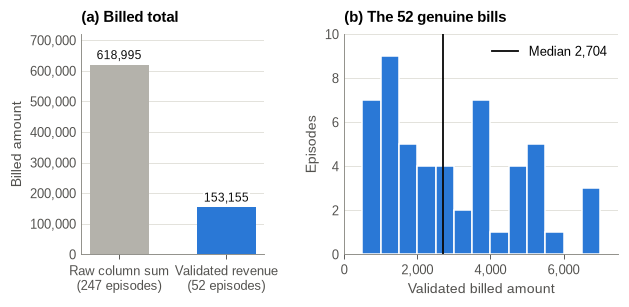

In [20]:
# @title Figure 2: Revenue gap and distribution of genuine bills

def plot_revenue_gap(df: pd.DataFrame) -> plt.Figure:
    """
    Compares the raw bill column sum with validated revenue, and shows the
    distribution of the genuine bills.

    Args:
        df: The cleaned register.

    Returns:
        The matplotlib figure.
    """
    bills = df["Bill_clean"].dropna()
    raw_total, valid_total = df["Bill"].sum(), bills.sum()

    fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, 2.6),
                             gridspec_kw={"width_ratios": [0.8, 1.2], "wspace": 0.35})

    ax = axes[0]
    bars = ax.bar(["Raw column sum\n(247 episodes)", "Validated revenue\n(52 episodes)"],
                  [raw_total, valid_total], color=[MUTED, PRIMARY], width=0.55)
    ax.set_ylim(0, 720_000)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
    ax.set_ylabel("Billed amount")
    ax.set_title("(a) Billed total")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    label_bars_v(ax, bars, [f"{raw_total:,.0f}", f"{valid_total:,.0f}"])

    ax = axes[1]
    ax.hist(bills, bins=np.arange(0, 7500, 500), color=PRIMARY,
            edgecolor="white", linewidth=1.0)
    ax.axvline(bills.median(), color=INK, linewidth=1.2)
    ax.set_xlim(0, 7500)
    ax.set_ylim(0, 10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(thousands))
    ax.set_xlabel("Validated billed amount")
    ax.set_ylabel("Episodes")
    ax.set_title("(b) The 52 genuine bills")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    ax.legend(handles=[Line2D([0], [0], color=INK, lw=1.2,
                              label=f"Median {bills.median():,.0f}")],
              loc="upper right")
    return fig


fig = plot_revenue_gap(clean_df)
save_figure(fig, "02_revenue_gap")
plt.show()

## Figure 3 - Case mix by diagnosis

Saved: ./figures/03_case_mix.png


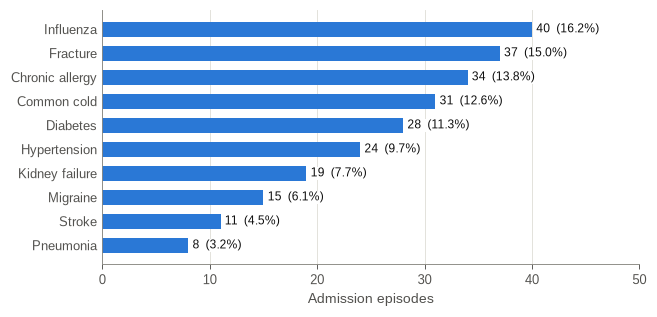

In [21]:
# @title Figure 3: Admission episodes by diagnosis

def plot_case_mix(df: pd.DataFrame) -> plt.Figure:
    """
    Plots the number of admission episodes per diagnosis.

    Args:
        df: The cleaned register.

    Returns:
        The matplotlib figure.
    """
    counts = df["Diagnosis"].value_counts().sort_values()
    n = len(df)

    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3.0))
    bars = ax.barh(counts.index, counts.values, color=PRIMARY, height=0.62)
    ax.set_xlim(0, 50)
    ax.set_xlabel("Admission episodes")
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)
    label_bars_h(ax, bars, [f"{v}  ({v / n * 100:.1f}%)" for v in counts.values], pad=0.008)
    return fig


fig = plot_case_mix(clean_df)
save_figure(fig, "03_case_mix")
plt.show()

## Figure 4 - Validated revenue by diagnosis

Both panels share the same diagnosis order. The number of genuine bills behind each diagnosis is written on the axis: a mean resting on one or two bills is not a benchmark.

Saved: ./figures/04_validated_revenue.png


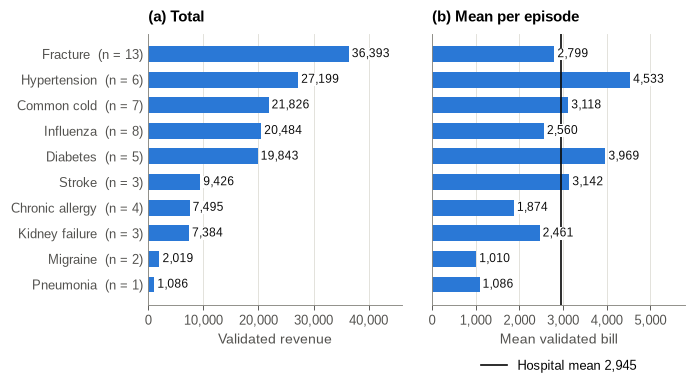

In [22]:
# @title Figure 4: Validated revenue and mean bill by diagnosis

def plot_validated_revenue(df: pd.DataFrame) -> plt.Figure:
    """
    Plots validated revenue and mean validated bill per diagnosis.

    Args:
        df: The cleaned register.

    Returns:
        The matplotlib figure.
    """
    valid = df.dropna(subset=["Bill_clean"])
    table = (valid.groupby("Diagnosis")["Bill_clean"]
             .agg(["count", "sum", "mean"]).sort_values("sum"))
    labels = [f"{d}  (n = {c})" for d, c in zip(table.index, table["count"])]
    hospital_mean = valid["Bill_clean"].mean()

    fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, 3.2), sharey=True,
                             gridspec_kw={"wspace": 0.12})

    ax = axes[0]
    bars = ax.barh(labels, table["sum"], color=PRIMARY, height=0.62)
    ax.set_xlim(0, 46_000)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(10_000))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(thousands))
    ax.set_xlabel("Validated revenue")
    ax.set_title("(a) Total")
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)
    label_bars_h(ax, bars, [f"{v:,.0f}" for v in table["sum"]], pad=0.012)

    ax = axes[1]
    bars = ax.barh(labels, table["mean"], color=PRIMARY, height=0.62)
    ax.axvline(hospital_mean, color=INK, linewidth=1.1)
    ax.set_xlim(0, 5_800)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1_000))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(thousands))
    ax.set_xlabel("Mean validated bill")
    ax.set_title("(b) Mean per episode")
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)
    label_bars_h(ax, bars, [f"{v:,.0f}" for v in table["mean"]], pad=0.012)
    ax.legend(handles=[Line2D([0], [0], color=INK, lw=1.1,
                              label=f"Hospital mean {hospital_mean:,.0f}")],
              loc="upper center", bbox_to_anchor=(0.5, -0.16))
    return fig


fig = plot_validated_revenue(clean_df)
save_figure(fig, "04_validated_revenue")
plt.show()

## Figure 5 - Admissions through the year

If admissions arrived at a constant rate, a monthly count would follow a Poisson distribution with the observed mean. The shaded band is the central 95% range of that distribution: a month inside it is compatible with chance alone.

Saved: ./figures/05_monthly_admissions.png


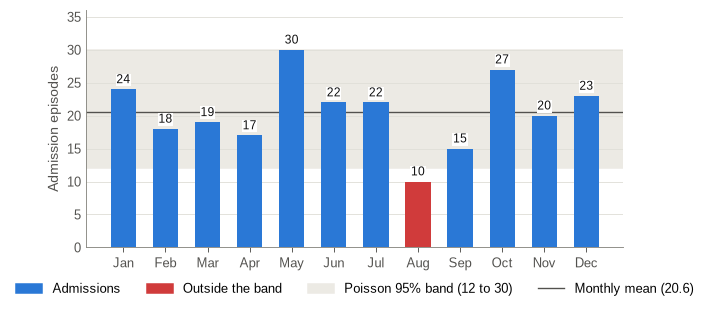

In [23]:
# @title Figure 5: Monthly admissions against the Poisson 95% band

def poisson_band(counts: pd.Series, level: float = 0.95) -> tuple:
    """
    Computes the central range a Poisson count with the observed mean falls in.

    Args:
        counts: The monthly admission counts.
        level: The coverage of the band.

    Returns:
        A tuple (mean, lower bound, upper bound).
    """
    mu = counts.mean()
    alpha = (1 - level) / 2
    return mu, stats.poisson.ppf(alpha, mu), stats.poisson.ppf(1 - alpha, mu)


def plot_monthly_admissions(df: pd.DataFrame) -> plt.Figure:
    """
    Plots monthly admissions against the range expected by chance.

    Args:
        df: The cleaned register.

    Returns:
        The matplotlib figure.
    """
    counts = df.groupby("AdmitMonth").size().reindex(range(1, 13), fill_value=0)
    months = pd.to_datetime(counts.index, format="%m").strftime("%b")
    mu, low, high = poisson_band(counts)
    outside = (counts < low) | (counts > high)

    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 2.8))
    ax.axhspan(low, high, color="#eceae4", zorder=0)
    ax.axhline(mu, color=INK_SECONDARY, linewidth=0.9, zorder=1)
    bars = ax.bar(months, counts.values, width=0.6, zorder=2,
                  color=[CRITICAL if o else PRIMARY for o in outside])
    ax.set_ylim(0, 36)
    ax.set_ylabel("Admission episodes")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    label_bars_v(ax, bars, [str(v) for v in counts.values])
    handles = [Patch(color=PRIMARY, label="Admissions"),
               Patch(color=CRITICAL, label="Outside the band"),
               Patch(color="#eceae4", label=f"Poisson 95% band ({low:.0f} to {high:.0f})"),
               Line2D([0], [0], color=INK_SECONDARY, lw=0.9, label=f"Monthly mean ({mu:.1f})")]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4)
    return fig


fig = plot_monthly_admissions(clean_df)
save_figure(fig, "05_monthly_admissions")
plt.show()

## Figure 6 - The five leading diagnoses by quarter

Saved: ./figures/06_diagnosis_by_quarter.png


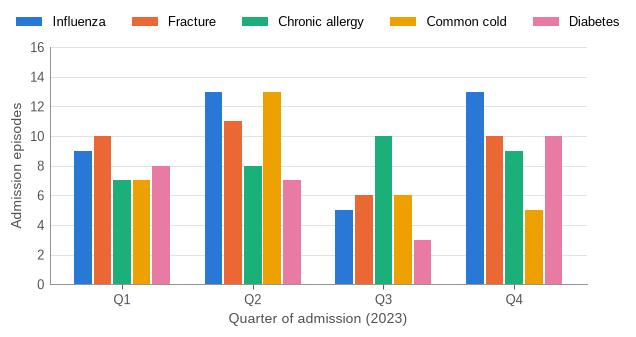

AdmitQuarter     Q1  Q2  Q3  Q4
Diagnosis                      
Influenza         9  13   5  13
Fracture         10  11   6  10
Chronic allergy   7   8  10   9
Common cold       7  13   6   5
Diabetes          8   7   3  10


In [24]:
# @title Figure 6: Leading diagnoses by quarter

def plot_diagnosis_by_quarter(df: pd.DataFrame, top_n: int = 5) -> tuple:
    """
    Plots the quarterly admissions of the leading diagnoses.

    Args:
        df: The cleaned register.
        top_n: The number of leading diagnoses to show.

    Returns:
        A tuple (figure, table of counts by diagnosis and quarter).
    """
    leaders = df["Diagnosis"].value_counts().index[:top_n]
    table = (pd.crosstab(df["Diagnosis"], df["AdmitQuarter"])
             .reindex(index=leaders, columns=["Q1", "Q2", "Q3", "Q4"]))

    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 2.8))
    width = 0.15
    x = np.arange(4)
    for i, diagnosis in enumerate(leaders):
        ax.bar(x + (i - (top_n - 1) / 2) * width, table.loc[diagnosis], width=width * 0.9,
               color=CATEGORY_COLORS[i], label=diagnosis)
    ax.set_xticks(x, ["Q1", "Q2", "Q3", "Q4"])
    ax.set_ylim(0, 16)
    ax.set_ylabel("Admission episodes")
    ax.set_xlabel("Quarter of admission (2023)")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=top_n)
    return fig, table


fig, quarter_table = plot_diagnosis_by_quarter(clean_df)
save_figure(fig, "06_diagnosis_by_quarter")
quarter_table.to_csv(drive_results_path + "by_diagnosis_quarter.csv")
plt.show()
print(quarter_table.to_string())

## Figure 7 - Acuity and insurance cover

Saved: ./figures/07_severity_insurance.png


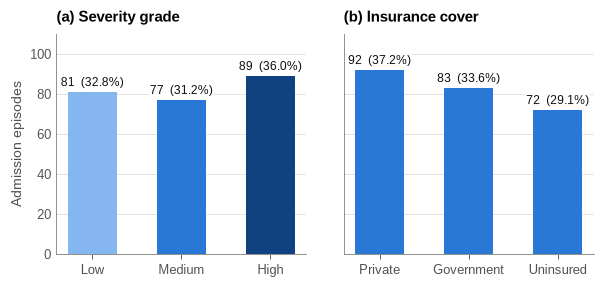

In [25]:
# @title Figure 7: Severity grade and insurance cover

def plot_severity_insurance(df: pd.DataFrame) -> plt.Figure:
    """
    Plots the distribution of severity grades and of insurance cover.

    Args:
        df: The cleaned register.

    Returns:
        The matplotlib figure.
    """
    n = len(df)
    severity = df["Severity"].value_counts().reindex(["Low", "Medium", "High"])
    insurance = df["Insurance"].value_counts().reindex(["Private", "Government", "Uninsured"])

    fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, 2.6), sharey=True,
                             gridspec_kw={"wspace": 0.15})
    panels = [(axes[0], severity, "(a) Severity grade",
               [SEVERITY_COLORS[k] for k in severity.index]),
              (axes[1], insurance, "(b) Insurance cover", [PRIMARY] * 3)]
    for ax, series, title, colors in panels:
        bars = ax.bar(series.index, series.values, color=colors, width=0.55)
        ax.set_ylim(0, 110)
        ax.set_title(title)
        ax.yaxis.grid(True)
        ax.set_axisbelow(True)
        label_bars_v(ax, bars, [f"{v}  ({v / n * 100:.1f}%)" for v in series.values])
    axes[0].set_ylabel("Admission episodes")
    return fig


fig = plot_severity_insurance(clean_df)
save_figure(fig, "07_severity_insurance")
plt.show()

## Figure 8 - Physician caseload and severity mix

Saved: ./figures/08_physicians.png


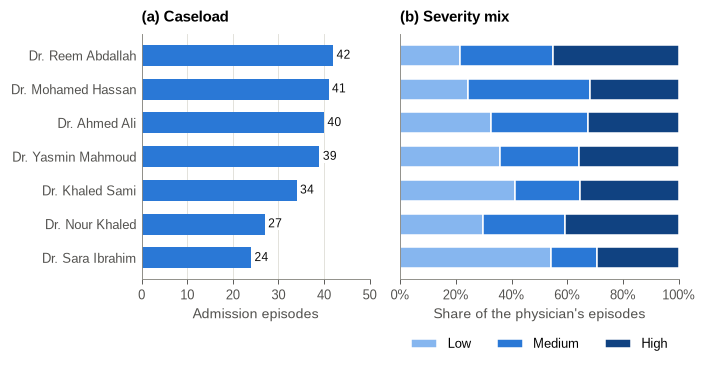

In [26]:
# @title Figure 8: Caseload and severity mix by physician

def plot_physicians(df: pd.DataFrame) -> plt.Figure:
    """
    Plots each physician's caseload and the severity mix of that caseload.

    Args:
        df: The cleaned register.

    Returns:
        The matplotlib figure.
    """
    caseload = df["Doctor"].value_counts().sort_values()
    mix = (pd.crosstab(df["Doctor"], df["Severity"], normalize="index")
           .reindex(index=caseload.index, columns=["Low", "Medium", "High"]) * 100)

    fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, 2.9), sharey=True,
                             gridspec_kw={"width_ratios": [0.9, 1.1], "wspace": 0.12})

    ax = axes[0]
    bars = ax.barh(caseload.index, caseload.values, color=PRIMARY, height=0.62)
    ax.set_xlim(0, 50)
    ax.set_xlabel("Admission episodes")
    ax.set_title("(a) Caseload")
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)
    label_bars_h(ax, bars, [str(v) for v in caseload.values], pad=0.015)

    ax = axes[1]
    left = np.zeros(len(mix))
    for grade in ["Low", "Medium", "High"]:
        ax.barh(mix.index, mix[grade], left=left, color=SEVERITY_COLORS[grade],
                height=0.62, edgecolor="white", linewidth=1.0, label=grade)
        left += mix[grade].values
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.set_xlabel("Share of the physician's episodes")
    ax.set_title("(b) Severity mix")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.19), ncol=3)
    return fig


fig = plot_physicians(clean_df)
save_figure(fig, "08_physicians")
plt.show()

## Figure 9 - Age profile and length of stay

Saved: ./figures/09_age_los.png


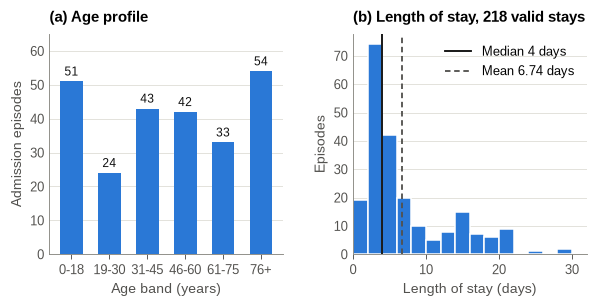

In [27]:
# @title Figure 9: Age bands and distribution of the length of stay

def plot_age_los(df: pd.DataFrame) -> plt.Figure:
    """
    Plots the admissions per age band and the distribution of valid stays.

    Args:
        df: The cleaned register.

    Returns:
        The matplotlib figure.
    """
    bands = df.sort_values("AgeBandOrder")["AgeBand"].unique()
    age = df["AgeBand"].value_counts().reindex(bands)
    los = df["LOS_valid"].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, 2.6), gridspec_kw={"wspace": 0.3})

    ax = axes[0]
    bars = ax.bar(age.index, age.values, color=PRIMARY, width=0.6)
    ax.set_ylim(0, 65)
    ax.set_xlabel("Age band (years)")
    ax.set_ylabel("Admission episodes")
    ax.set_title("(a) Age profile")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    label_bars_v(ax, bars, [str(v) for v in age.values])

    ax = axes[1]
    ax.hist(los, bins=np.arange(0, 32, 2), color=PRIMARY, edgecolor="white", linewidth=1.0)
    ax.axvline(los.median(), color=INK, linewidth=1.2)
    ax.axvline(los.mean(), color=INK_SECONDARY, linewidth=1.2, linestyle=(0, (3, 2)))
    ax.set_xlim(0, 32)
    ax.set_xlabel("Length of stay (days)")
    ax.set_ylabel("Episodes")
    ax.set_title(f"(b) Length of stay, {len(los)} valid stays")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    ax.legend(handles=[Line2D([0], [0], color=INK, lw=1.2, label=f"Median {los.median():.0f} days"),
                       Line2D([0], [0], color=INK_SECONDARY, lw=1.2, linestyle=(0, (3, 2)),
                              label=f"Mean {los.mean():.2f} days")],
              loc="upper right")
    return fig


fig = plot_age_los(clean_df)
save_figure(fig, "09_age_los")
plt.show()

## Figure 10 - Does acuity drive the stay and the bill?

Box plots show the median (black line), the interquartile range (box) and the spread (whiskers at 1.5 times the interquartile range). Each box states the number of episodes it rests on.

Saved: ./figures/10_severity_outcomes.png


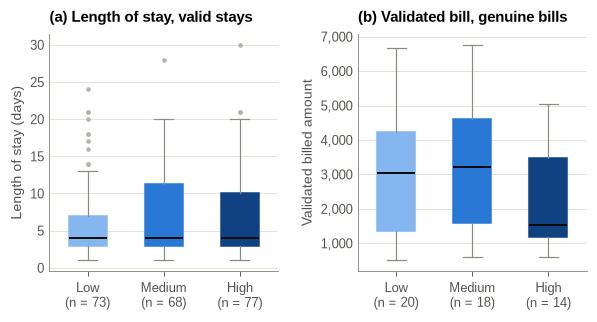

In [28]:
# @title Figure 10: Length of stay and validated bill by severity grade

def plot_severity_outcomes(df: pd.DataFrame) -> plt.Figure:
    """
    Plots the distribution of length of stay and validated bill per severity grade.

    Args:
        df: The cleaned register.

    Returns:
        The matplotlib figure.
    """
    grades = ["Low", "Medium", "High"]
    panels = [("LOS_valid", "Length of stay (days)", "(a) Length of stay, valid stays"),
              ("Bill_clean", "Validated billed amount", "(b) Validated bill, genuine bills")]

    fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, 2.8), gridspec_kw={"wspace": 0.35})
    for ax, (column, ylabel, title) in zip(axes, panels):
        groups = [df.loc[df["Severity"] == g, column].dropna() for g in grades]
        box = ax.boxplot(groups, widths=0.5, patch_artist=True,
                         medianprops={"color": INK, "linewidth": 1.3},
                         whiskerprops={"color": AXIS, "linewidth": 0.8},
                         capprops={"color": AXIS, "linewidth": 0.8},
                         flierprops={"marker": "o", "markersize": 3,
                                     "markerfacecolor": MUTED, "markeredgecolor": "none"})
        for patch, grade in zip(box["boxes"], grades):
            patch.set_facecolor(SEVERITY_COLORS[grade])
            patch.set_edgecolor(SEVERITY_COLORS[grade])
        ax.set_xticks([1, 2, 3], [f"{g}\n(n = {len(x)})" for g, x in zip(grades, groups)])
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.yaxis.grid(True)
        ax.set_axisbelow(True)
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
    return fig


fig = plot_severity_outcomes(clean_df)
save_figure(fig, "10_severity_outcomes")
plt.show()

## Figure 11 - What drives the bill?

Panel (a) gives the Spearman rank correlation between the four numeric measures, each computed on the episodes where both values are valid. Panel (b) plots the strongest pair.

    variable_1     variable_2  spearman_rho  p_value   n
           Age       Severity         0.015 0.810845 247
           Age Length of stay         0.132 0.051777 218
           Age Validated bill         0.110 0.438484  52
      Severity Length of stay         0.001 0.987580 218
      Severity Validated bill        -0.140 0.320772  52
Length of stay Validated bill         0.620 0.000002  50
Least-squares fit: bill = 1,123 + 529 x days


Saved: ./figures/11_correlations.png


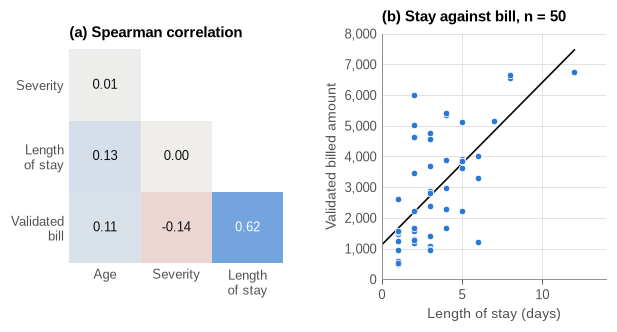

In [29]:
# @title Figure 11: Correlations and the stay-bill relationship

CORRELATION_VARIABLES = {"Age": "Age", "SeverityRank": "Severity",
                         "LOS_valid": "Length of stay", "Bill_clean": "Validated bill"}
SHORT_NAMES = {"Age": "Age", "Severity": "Severity",
               "Length of stay": "Length\nof stay", "Validated bill": "Validated\nbill"}


def correlation_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes pairwise Spearman correlations on the valid values of each pair.

    Args:
        df: The cleaned register.

    Returns:
        A DataFrame with one row per pair: rho, p-value and number of episodes.
    """
    keys = list(CORRELATION_VARIABLES)
    rows = []
    for i, a in enumerate(keys):
        for b in keys[i + 1:]:
            pair = df[[a, b]].dropna()
            rho, p = stats.spearmanr(pair[a], pair[b])
            rows.append({"variable_1": CORRELATION_VARIABLES[a],
                         "variable_2": CORRELATION_VARIABLES[b],
                         "spearman_rho": round(rho, 3), "p_value": p, "n": len(pair)})
    return pd.DataFrame(rows)


def plot_correlations(df: pd.DataFrame, corr: pd.DataFrame) -> plt.Figure:
    """
    Plots the correlation matrix and the length of stay against the bill.

    Args:
        df: The cleaned register.
        corr: The pairwise correlation table.

    Returns:
        The matplotlib figure.
    """
    names = list(CORRELATION_VARIABLES.values())
    matrix = pd.DataFrame(np.nan, index=names, columns=names)
    for _, r in corr.iterrows():
        matrix.loc[r["variable_2"], r["variable_1"]] = r["spearman_rho"]

    fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, 2.9),
                             gridspec_kw={"width_ratios": [1, 1.05], "wspace": 0.45})

    ax = axes[0]
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
        "diverging", ["#d03b3b", "#f0efec", "#2a78d6"])
    shown = matrix.iloc[1:, :-1]
    ax.imshow(shown.values, cmap=cmap, vmin=-1, vmax=1)
    for i in range(shown.shape[0]):
        for j in range(shown.shape[1]):
            value = shown.iat[i, j]
            if not np.isnan(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8.5,
                        color="white" if abs(value) > 0.5 else INK)
    ax.set_xticks(range(shown.shape[1]), [SHORT_NAMES[c] for c in shown.columns])
    ax.set_yticks(range(shown.shape[0]), [SHORT_NAMES[c] for c in shown.index])
    ax.tick_params(length=0)
    for side in ["left", "bottom"]:
        ax.spines[side].set_visible(False)
    ax.set_title("(a) Spearman correlation")

    ax = axes[1]
    pair = df[["LOS_valid", "Bill_clean"]].dropna()
    slope, intercept = np.polyfit(pair["LOS_valid"], pair["Bill_clean"], 1)
    x_line = np.array([0, pair["LOS_valid"].max()])
    ax.scatter(pair["LOS_valid"], pair["Bill_clean"], s=18, color=PRIMARY,
               edgecolor="white", linewidth=0.5, zorder=3)
    ax.plot(x_line, intercept + slope * x_line, color=INK, linewidth=1.1, zorder=2)
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 8000)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
    ax.set_xlabel("Length of stay (days)")
    ax.set_ylabel("Validated billed amount")
    ax.set_title(f"(b) Stay against bill, n = {len(pair)}")
    ax.grid(True)
    ax.set_axisbelow(True)
    print(f"Least-squares fit: bill = {intercept:,.0f} + {slope:,.0f} x days")
    return fig


corr_df = correlation_table(clean_df)
corr_df.to_csv(drive_results_path + "correlations.csv", index=False)
print(corr_df.to_string(index=False))

fig = plot_correlations(clean_df, corr_df)
save_figure(fig, "11_correlations")
plt.show()

## Figure 12 - Are the 52 genuine bills representative?

Validated revenue can stand for the whole hospital only if the genuine bills are spread like the other episodes. The figure gives, for each length-of-stay band, the share of episodes whose bill is genuine.

            episodes  genuine_bills  genuine_share_%
los_band                                            
1-3 days          93             30             32.3
4-6 days          53             16             30.2
7-9 days          19              3             15.8
10-12 days        10              1             10.0
13-30 days        43              0              0.0


Saved: ./figures/12_genuine_bills_by_stay.png


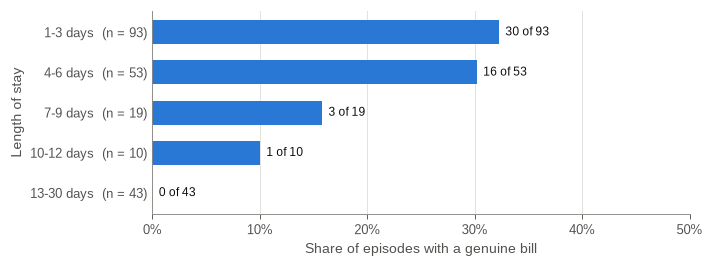

In [30]:
# @title Figure 12: Share of genuine bills by length-of-stay band

LOS_BANDS = [0, 3, 6, 9, 12, 31]
LOS_BAND_LABELS = ["1-3 days", "4-6 days", "7-9 days", "10-12 days", "13-30 days"]


def genuine_share_by_stay(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes the share of episodes with a genuine bill in each length-of-stay band.

    Args:
        df: The cleaned register.

    Returns:
        A DataFrame with, per band, the episodes, the genuine bills and their share.
    """
    valid = df.dropna(subset=["LOS_valid"]).copy()
    valid["los_band"] = pd.cut(valid["LOS_valid"], LOS_BANDS, labels=LOS_BAND_LABELS)
    table = valid.groupby("los_band", observed=False).agg(
        episodes=("EpisodeID", "count"),
        genuine_bills=("Bill_clean", "count"))
    table["genuine_share_%"] = table["genuine_bills"] / table["episodes"] * 100
    return table


def plot_genuine_share(table: pd.DataFrame) -> plt.Figure:
    """
    Plots the share of episodes with a genuine bill per length-of-stay band.

    Args:
        table: The output of genuine_share_by_stay.

    Returns:
        The matplotlib figure.
    """
    labels = [f"{band}  (n = {n})" for band, n in zip(table.index, table["episodes"])]
    colors = [CRITICAL if v == 0 else PRIMARY for v in table["genuine_share_%"]]

    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 2.4))
    bars = ax.barh(labels[::-1], table["genuine_share_%"].values[::-1],
                   color=colors[::-1], height=0.6)
    ax.set_xlim(0, 50)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.set_xlabel("Share of episodes with a genuine bill")
    ax.set_ylabel("Length of stay")
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)
    label_bars_h(ax, bars, [f"{g} of {n}" for g, n in
                            zip(table["genuine_bills"].values[::-1], table["episodes"].values[::-1])],
                 pad=0.012)
    return fig


genuine_table = genuine_share_by_stay(clean_df)
genuine_table.to_csv(drive_results_path + "genuine_bills_by_stay.csv")
print(genuine_table.round(1).to_string())

fig = plot_genuine_share(genuine_table)
save_figure(fig, "12_genuine_bills_by_stay")
plt.show()

<a name="statistical-tests"></a>
# 10. Statistical Tests

A difference seen in a chart is a finding only if chance alone is unlikely to produce it. The tests below are non-parametric where the distributions are skewed (length of stay and bills are both right-skewed).

| Question | Test | Null hypothesis |
|---|---|---|
| Does length of stay differ by severity? | Kruskal-Wallis | Same distribution in the three grades |
| Does the validated bill differ by severity? | Kruskal-Wallis | Same distribution in the three grades |
| Does the severity mix differ between physicians? | Chi-square of independence | Severity independent of physician |
| Does the severity mix differ by insurance cover? | Chi-square of independence | Severity independent of cover |
| Are admissions evenly spread across months? | Chi-square goodness of fit | Same expected count every month |
| Is length of stay related to the bill? | Spearman rank correlation | No monotonic association |
| Are genuine bills on stays of the same length as placeholder bills? | Mann-Whitney U | Same distribution of stay |

In [31]:
# @title Run the statistical tests

def run_tests(df: pd.DataFrame) -> pd.DataFrame:
    """
    Runs the seven statistical tests of the report.

    Args:
        df: The cleaned register.

    Returns:
        A DataFrame with the test, its statistic, p-value and base.
    """
    grades = ["Low", "Medium", "High"]
    rows = []

    for column, label in [("LOS_valid", "Length of stay by severity"),
                          ("Bill_clean", "Validated bill by severity")]:
        groups = [df.loc[df["Severity"] == g, column].dropna() for g in grades]
        h, p = stats.kruskal(*groups)
        rows.append((label, "Kruskal-Wallis H", h, p, sum(len(g) for g in groups)))

    for key, label in [("Doctor", "Severity mix by physician"),
                       ("Insurance", "Severity mix by insurance cover")]:
        chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(df[key], df["Severity"]))
        rows.append((label, f"Chi-square ({dof} df)", chi2, p, len(df)))

    monthly = df.groupby("AdmitMonth").size()
    chi2, p = stats.chisquare(monthly)
    rows.append(("Admissions evenly spread over months", "Chi-square (11 df)", chi2, p, len(df)))

    pair = df[["LOS_valid", "Bill_clean"]].dropna()
    rho, p = stats.spearmanr(pair["LOS_valid"], pair["Bill_clean"])
    rows.append(("Length of stay against validated bill", "Spearman rho", rho, p, len(pair)))

    has_bill = df["Bill_clean"].notna()
    u, p = stats.mannwhitneyu(df.loc[has_bill, "LOS_valid"].dropna(),
                              df.loc[~has_bill, "LOS_valid"].dropna())
    rows.append(("Stay of genuine against placeholder bills", "Mann-Whitney U", u, p,
                 int(df["LOS_valid"].notna().sum())))

    table = pd.DataFrame(rows, columns=["test", "statistic_name", "statistic", "p_value", "n"])
    table["significant_at_5%"] = table["p_value"] < 0.05
    return table


tests_df = run_tests(clean_df)
tests_df.to_csv(drive_results_path + "statistical_tests.csv", index=False)
with pd.option_context("display.float_format", "{:.4f}".format):
    print(tests_df.to_string(index=False))

                                     test     statistic_name  statistic  p_value   n  significant_at_5%
               Length of stay by severity   Kruskal-Wallis H     0.3454   0.8414 218              False
               Validated bill by severity   Kruskal-Wallis H     2.5134   0.2846  52              False
                Severity mix by physician Chi-square (12 df)    13.4015   0.3405 247              False
          Severity mix by insurance cover  Chi-square (4 df)     1.1887   0.8799 247              False
     Admissions evenly spread over months Chi-square (11 df)    15.3968   0.1650 247              False
    Length of stay against validated bill       Spearman rho     0.6203   0.0000  50               True
Stay of genuine against placeholder bills     Mann-Whitney U  2458.0000   0.0000 218               True


In [32]:
# @title Monthly counts against the Poisson band

monthly = clean_df.groupby("AdmitMonth").size()
mu, low, high = poisson_band(monthly)
print(f"Monthly mean: {mu:.2f}   Poisson 95% band: {low:.0f} to {high:.0f}")
print(f"Months outside the band: "
      f"{[pd.Timestamp(2023, m, 1).strftime('%B') for m in monthly.index[(monthly < low) | (monthly > high)]]}")
print(f"Months expected outside a 95% band by chance alone, out of 12: {12 * 0.05:.1f}")

Monthly mean: 20.58   Poisson 95% band: 12 to 30
Months outside the band: ['August']
Months expected outside a 95% band by chance alone, out of 12: 0.6


**Remark** ✅

- **Severity explains neither the stay nor the bill** ($p = 0.84$ and $p = 0.28$). The median stay is 4 days in all three grades.
- **The severity mix does not differ between physicians** ($p = 0.34$) **or between insurance covers** ($p = 0.88$). A physician ranking on this sample would judge noise.
- **Admissions are compatible with an even spread across months** ($p = 0.17$). One month (August, 10 admissions) falls below the 95% band, which is about what chance alone produces over twelve months (0.6 expected). May, at 30, sits on the upper edge of the band, not outside it.
- **Length of stay is the one strong driver of the bill** ($\rho = 0.62$, $p < 0.001$, 50 episodes). Each additional day adds about 530 to the validated bill, over the range observed (1 to 12 days).
- **The genuine bills are not representative.** They sit on short stays (median 3 days against 5 for placeholder bills, $p < 0.001$), and none of the 43 stays longer than 12 days has a genuine bill. Since the bill rises with the stay, the mean validated bill of 2,945 understates the typical bill and must not be multiplied by 247 to estimate annual revenue.

<a name="insights"></a>
# 11. Insights & Recommendations

In [33]:
# @title Export the key findings for the report and the dashboard

kpis = dict(zip(kpi_df["indicator"], kpi_df["value"]))
findings = {
    "episodes": int(kpis["Admission episodes"]),
    "patients": int(kpis["Distinct patients"]),
    "physicians": int(kpis["Attending physicians"]),
    "diagnoses": int(kpis["Distinct diagnoses"]),
    "placeholder_bills": int(clean_df["BillIsPlaceholder"].sum()),
    "genuine_bills": int(clean_df["Bill_clean"].notna().sum()),
    "date_errors": int(clean_df["DateError"].sum()),
    "valid_stays": int(clean_df["LOS_valid"].notna().sum()),
    "raw_bill_sum": float(kpis["Raw bill column sum"]),
    "validated_revenue": float(kpis["Validated revenue"]),
    "mean_los_days": float(kpis["Mean length of stay (days)"]),
    "median_los_days": float(kpis["Median length of stay (days)"]),
    "high_severity_pct": float(kpis["High severity share (%)"]),
    "uninsured_pct": float(kpis["Uninsured share (%)"]),
    "tests": tests_df.drop(columns="significant_at_5%").to_dict(orient="records"),
}
with open(drive_results_path + "findings.json", "w") as f:
    json.dump(findings, f, indent=2, default=float)

pprint({k: v for k, v in findings.items() if k != "tests"})

{'date_errors': 29,
 'diagnoses': 10,
 'episodes': 247,
 'genuine_bills': 52,
 'high_severity_pct': 36.0,
 'mean_los_days': 6.74,
 'median_los_days': 4.0,
 'patients': 75,
 'physicians': 7,
 'placeholder_bills': 195,
 'raw_bill_sum': 618995.0,
 'uninsured_pct': 29.1,
 'valid_stays': 218,
 'validated_revenue': 153155.0}


### 1. Billing integrity is the primary risk
195 of 247 episodes (78.9%) carry a placeholder amount. The raw bill column sums to 618,995; validated revenue is **153,155**, on 52 genuine bills. The raw total overstates validated revenue by a factor of four.

The 52 genuine bills are also a biased sample: they cover short stays almost exclusively, and none of the 43 stays longer than 12 days has one. Validated revenue is therefore a **floor**, not an estimate: the mean validated bill cannot be scaled up to the 247 episodes.

**Recommendation.** Publish finance indicators on validated bills only, state the 52-episode base beside every amount, and do not extrapolate them. Audit the charge-capture path that writes 999 and 3,852 before the next reporting cycle, starting with long stays, where no genuine bill exists.

### 2. Date errors break the stay benchmark
29 episodes (11.7%) record a discharge before the admission. Mean length of stay on the 218 valid stays is **6.74 days**, median 4 days.

**Recommendation.** Block the save when the discharge date precedes the admission date. One validation rule at entry would have preserved 11.7% of the year's operational record.

### 3. Length of stay, not severity, drives the bill
The bill rises with the stay ($\rho = 0.62$, $p < 0.001$), by about 530 per day over the 1 to 12 days observed. It does not rise with severity ($p = 0.28$), and neither does the stay ($p = 0.84$).

**Recommendation.** Manage cost through discharge planning for long stays: 24% of valid stays exceed 9 days. Audit how the severity grade is assigned at admission: a triage grade that predicts neither stay nor bill needs correcting.

### 4. Case mix is concentrated, and acuity and cover create pressure together
Influenza, fracture and chronic allergy account for 45% of admissions. 36.0% of admissions are graded high severity and 29.1% arrive uninsured.

**Recommendation.** Align bed, pharmacy and pathway capacity with the three leading diagnoses. Move financial counselling for uninsured patients to admission.

### 5. The monthly profile does not support a seasonal roster
Admissions are compatible with an even spread across the year ($p = 0.17$). Only August falls outside the band expected by chance.

**Recommendation.** Do not build a staffing roster on the shape of a single year. Re-test seasonality when a second year of data is available.

<a name="dashboard"></a>
# 12. Interactive Dashboard

`dashboard.html` is a single self-contained file: open it in a modern browser, no server and no installation required. Its seven views (Overview, Dashboard, Patients, Clinical, Financial, Data Quality, Insights) are documented with captures in section 6 of the report.

> **Reading note.** Three dashboard elements use a different base from this notebook. The *Revenue* tile and the *Revenue by diagnosis, by insurance* and *Revenue trend* charts sum the raw bill column (618,995), not validated revenue. The *Billing quality* alert and the *Clinical correlations* cards treat only 999 as a placeholder, so they keep the 95 bills at 3,852: the alert reports 100 placeholders instead of 195, and the stay-bill card reports 0.31 instead of 0.66 (Pearson, 50 genuine bills with a valid stay). The figures of this notebook are the reference.

In [34]:
# @title Pearson correlation on the dashboard's two bases (reconciliation)

# Base used by this notebook: genuine bills only (999 and 3,852 excluded)
pair = clean_df[["LOS_valid", "Bill_clean"]].dropna()
r_valid = stats.pearsonr(pair["LOS_valid"], pair["Bill_clean"])[0]

# Base used by the dashboard correlation cards: only 999 excluded
dash_bill = clean_df["Bill"].where(clean_df["Bill"] != 999)
pair_dash = pd.concat([clean_df["LOS_valid"], dash_bill], axis=1).dropna()
r_dash = stats.pearsonr(pair_dash["LOS_valid"], pair_dash["Bill"])[0]

print(f"Stay-bill Pearson r, genuine bills only : {r_valid:.2f}  (n = {len(pair)})")
print(f"Stay-bill Pearson r, 3,852 kept as valid : {r_dash:.2f}  (n = {len(pair_dash)})")

Stay-bill Pearson r, genuine bills only : 0.66  (n = 50)
Stay-bill Pearson r, 3,852 kept as valid : 0.31  (n = 133)


<a name="limitations"></a>
# 13. Limitations & Future Works

* **Revenue rests on 52 episodes, concentrated on short stays.** No financial figure in this notebook is a budget input until the billing column is repaired at source. Means by diagnosis rest on 1 to 13 bills each, and the stay-bill slope is only observed between 1 and 12 days.

* **Length of stay rests on 218 episodes**, 88.3% of the file.

* **Small sample for the number of segments.** 247 episodes across 10 diagnoses and 7 physicians leaves several segments in single figures. Every segment comparison is reported with its test.

* **One facility, one year.** There is no ward or site column, so no comparison between units is possible, and a single year supports no trend or seasonality claim.

* **Association, not causation.** The stay-bill relationship shows that the bill follows the stay; it does not show why stays are long.

**Future works.** Repair the billing and date capture at source, then re-run this notebook unchanged: every flag, table and figure is recomputed from the primary columns. Add a second year to test seasonality, and a ward column to compare units.

<a name="references"></a>
# 14. References

* Gebru, T. et al. (2021). Datasheets for Datasets. *Communications of the ACM*, 64(12): https://arxiv.org/abs/1803.09010
* Kruskal, W. H. and Wallis, W. A. (1952). Use of ranks in one-criterion variance analysis. *Journal of the American Statistical Association*, 47(260), 583-621.
* Spearman, C. (1904). The proof and measurement of association between two things. *American Journal of Psychology*, 15(1), 72-101.
* Virtanen, P. et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261-272.
* Hunter, J. D. (2007). Matplotlib: a 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90-95.
* McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56-61.